**Apply the Horvath 2013 clock** — run published coefficients on a public
methylation dataset and plot predicted vs. chronological age. No training.

- Clock: Horvath, *Genome Biology* 14, R115 (2013), `CoefficientTraining` (353 CpGs). File + SHA in `docs/data-sources.md`.
- Data: GEO **GSE40279** (Hannum 2013), 656 blood samples, ages 19–101, 450K.

# SETUP

## Import

In [7]:
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pooch

## Constants

In [8]:
PATH_DATA_RAW = Path("..") / "data" / "raw"
ACCESSION = "GSE40279"
PATH_COEF = PATH_DATA_RAW / "horvath2013_coefficients.csv"
PATH_METHYLATION = PATH_DATA_RAW / f"{ACCESSION}_series_matrix.txt.gz"
ADULT_AGE = 20  # child/adult boundary in Horvath's age transform

# DATA

## Download

In [9]:
COEF_URL = "https://static-content.springer.com/esm/art%3A10.1186%2Fgb-2013-14-10-r115/MediaObjects/13059_2013_3156_MOESM3_ESM.csv"
SERIES_URL = f"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE40nnn/{ACCESSION}/matrix/{ACCESSION}_series_matrix.txt.gz"

# fetch into data/raw, SHA-verified where recorded (docs/data-sources.md)
pooch.retrieve(COEF_URL, "sha256:1d028d6ac2ca8fb4bc05f3a1453574f167b24e56414cc66512a854a5ac65f88c",
               fname=PATH_COEF.name, path=PATH_DATA_RAW)
pooch.retrieve(SERIES_URL, None,  # GSE40279 SHA not yet recorded — pooch prints it
               fname=PATH_METHYLATION.name, path=PATH_DATA_RAW)

'/home/asdf/playground-aging-clocks/data/raw/GSE40279_series_matrix.txt.gz'

## Load
Horvath coefficients, then the GEO series matrix (CpG×sample β + per-sample age).

In [10]:
coef_df = pd.read_csv(PATH_COEF, skiprows=2)  # 2-line preamble before the header
coefs = coef_df.set_index("CpGmarker")["CoefficientTraining"]
intercept = coefs["(Intercept)"]
coef = coefs.drop("(Intercept)")  # the 353 CpG coefficients

# sanity checks from docs/data-sources.md
assert round(intercept, 9) == 0.695507258
assert len(coef) == 353
assert round(coef["cg00075967"], 8) == 0.12933661
intercept, coef.shape

(np.float64(0.695507258), (353,))

In [11]:
# GEO series matrix: '!'-prefixed metadata lines, then a CpG×sample beta table
gsm_ids: list[str] = []
ages: list[float] = []
with gzip.open(PATH_METHYLATION, "rt") as fh:
    for line in fh:
        if line.startswith("!Sample_geo_accession"):
            gsm_ids = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
        elif line.startswith("!Sample_characteristics_ch1"):
            vals = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
            if vals and vals[0].lower().startswith("age"):  # 'age (y): 67'
                ages = [float(v.split(":")[1]) for v in vals]

beta = pd.read_csv(PATH_METHYLATION, sep="\t", comment="!", index_col=0)  # comment drops metadata
age = pd.Series(ages, index=gsm_ids, name="age").reindex(beta.columns)
beta.shape, age.describe()

((473034, 656),
 count    656.000000
 mean      64.035061
 std       14.736681
 min       19.000000
 25%       54.000000
 50%       65.000000
 75%       75.000000
 max      101.000000
 Name: age, dtype: float64)

# PREDICT
`intercept + Σ coef·β` over shared CpGs, then invert the age transform.

In [12]:
shared = coef.index.intersection(beta.index)
print(f"{len(shared)}/{len(coef)} clock CpGs present on the array")

x = beta.loc[shared].apply(lambda row: row.fillna(row.mean()), axis=1)  # impute dropped probes
t = intercept + coef[shared] @ x  # transformed age, Horvath's scale
pred = pd.Series(
    np.where(t < 0, (1 + ADULT_AGE) * np.exp(t) - 1, (1 + ADULT_AGE) * t + ADULT_AGE),
    index=t.index, name="pred_age",
)

result = pd.concat([age, pred], axis=1)
result.head(30)

353/353 clock CpGs present on the array


,age,pred_age
GSM989827,67.0,52.161142
GSM989828,89.0,75.446216
GSM989829,66.0,62.602883
GSM989830,64.0,54.249671
GSM989831,62.0,62.947226
GSM989832,87.0,76.986661
GSM989833,73.0,68.582725
GSM989834,75.0,64.814253
GSM989835,73.0,66.188440
GSM989836,83.0,79.134202


# RESULTS

## Figures
Points on the dashed `y = x` = the clock transfers.

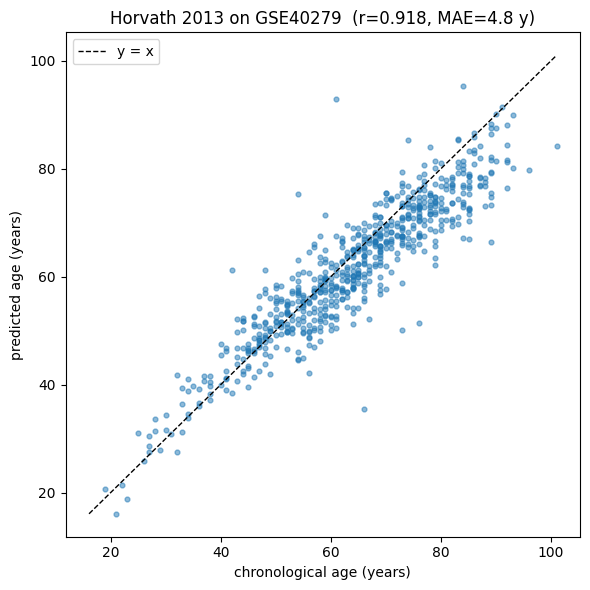

In [7]:
r = result["age"].corr(result["pred_age"])
mae = (result["pred_age"] - result["age"]).abs().mean()

lo, hi = result.min().min(), result.max().max()
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(result["age"], result["pred_age"], s=12, alpha=0.5)
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax.set(xlabel="chronological age (years)", ylabel="predicted age (years)",
       title=f"Horvath 2013 on {ACCESSION}  (r={r:.3f}, MAE={mae:.1f} y)")
ax.legend()
fig.tight_layout()